# Análise Avançada de Machine Learning — Uso de Cosméticos
**Modelos:** Random Forest · Naive Bayes · Gradient Boosting · SHAP · Regras de Associação (Apriori) · Análise de Perfis de Risco · Curvas de Aprendizado

> Este notebook complementa as análises descritivas e estatísticas já realizadas, aplicando técnicas supervisionadas e não supervisionadas para predição, interpretação e descoberta de padrões.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     learning_curve, cross_validate)
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

# SHAP
try:
    import shap
    SHAP_OK = True
except:
    SHAP_OK = False
    print("SHAP nao disponivel")

# Apriori / regras de associacao
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_OK = True
except:
    MLXTEND_OK = False
    print("mlxtend nao disponivel")

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})
PALETTE = ['#6C63FF','#FF6584','#43B89C','#FFC75F','#845EC2','#FF9671','#0081CF','#D65DB1']
sns.set_palette(PALETTE)
print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 1. Carregamento e Engenharia de Features

In [2]:

FILE = '/mnt/user-data/uploads/Uso_de_cosm\u00e9ticos_causas_e_consequ\u00eancias___respostas__-_Respostas_ao_formul\u00e1rio_1__1_.csv'
df_raw = pd.read_csv(FILE)

COL = {
    df_raw.columns[2]:  'genero',
    df_raw.columns[5]:  'idade',
    df_raw.columns[6]:  'escolaridade',
    df_raw.columns[7]:  'influencia_compra',
    df_raw.columns[8]:  'conhece_efeitos',
    df_raw.columns[9]:  'ativos_usados',
    df_raw.columns[10]: 'qtd_produto_ideal',
    df_raw.columns[11]: 'sobreposicao_ativo',
    df_raw.columns[12]: 'metodo_nao_convencional',
    df_raw.columns[13]: 'num_produtos',
    df_raw.columns[14]: 'motivacao',
    df_raw.columns[15]: 'crenca_natural',
    df_raw.columns[16]: 'sintomas_12m',
    df_raw.columns[17]: 'resposta_sintoma',
    df_raw.columns[18]: 'tempo_recuperacao',
    df_raw.columns[19]: 'combinacao_ativos',
    df_raw.columns[20]: 'diagnostico_medico',
    df_raw.columns[21]: 'automedicacao_6m',
}
df = df_raw.rename(columns=COL)[list(COL.values())].copy()
df = df[df['genero'].notna()].copy()

# ── Ordinais ──────────────────────────────────────────────────────
df['num_produtos_ord'] = df['num_produtos'].map({
    'Nenhum':0,'1 a 2 produtos':1,'3 a 5 produtos':2,
    '6 a 8 produtos':3,'9 ou mais produtos':4})
df['escolaridade_ord'] = df['escolaridade'].map({
    'Ensino M\u00e9dio Incompleto/Completo':1,
    'Ensino Superior Incompleto':2,
    'Ensino Superior Completo':3,
    'P\u00f3s-gradua\u00e7\u00e3o (Especializa\u00e7\u00e3o; Mestrado; Doutorado)':4})
df['tempo_rec_ord'] = df['tempo_recuperacao'].map({
    'Nunca tive uma rea\u00e7\u00e3o vis\u00edvel':0,
    'Menos de 24 horas':1,'1 a 3 dias':2,'4 a 7 dias':3,'Mais de uma semana':4})

# ── Binarios ──────────────────────────────────────────────────────
df['automedicacao_bin'] = (df['automedicacao_6m'] == 'Sim').astype(int)
df['sobreposicao_bin']  = (df['sobreposicao_ativo'] == 'Sim').astype(int)
df['conhece_bin']       = (df['conhece_efeitos'] == 'Sim').astype(int)
df['genero_bin']        = (df['genero'] == 'Feminino').astype(int)
df['crenca_natural_bin']= df['crenca_natural'].str.startswith('Sim', na=False).astype(int)
df['teve_sintoma']      = (~df['sintomas_12m'].str.contains('N\u00e3o apresentei', na=True)).astype(int)
df['uso_alto']          = (df['num_produtos_ord'] >= 3).astype(int)
df['tem_diagnostico']   = df['diagnostico_medico'].apply(
    lambda x: 0 if pd.isna(x) or 'Nunca' in str(x) else 1)
df['continua_uso']      = df['resposta_sintoma'].str.contains('acostumar', na=False).astype(int)
df['nao_sei_combo']     = df['combinacao_ativos'].str.contains('sei', case=False, na=False).astype(int)
df['metodo_nao_conv']   = df['metodo_nao_convencional'].apply(
    lambda x: 0 if pd.isna(x) or 'N\u00e3o' in str(x) else 1)

# ── Multi-selects: contagens ──────────────────────────────────────
df['n_ativos'] = df['ativos_usados'].fillna('').apply(
    lambda x: len([i for i in x.split(',') if i.strip() and 'Nenhuma' not in i]))

df['n_influencias'] = df['influencia_compra'].fillna('').apply(
    lambda x: len([i for i in x.split(',') if i.strip()]))

df['n_sintomas'] = df['sintomas_12m'].fillna('').apply(
    lambda x: len([i for i in x.split(',') if i.strip() and 'apresentei' not in i.lower()]))

df['n_diagnosticos'] = df['diagnostico_medico'].fillna('').apply(
    lambda x: len([i for i in x.split(',') if i.strip() and 'Nunca' not in i]))

# ── Score de Risco Composto (0-7) ────────────────────────────────
df['risk_score'] = (
    df['automedicacao_bin'] +
    df['sobreposicao_bin'] +
    df['crenca_natural_bin'] +
    df['nao_sei_combo'] +
    df['continua_uso'] +
    df['metodo_nao_conv'] +
    df['uso_alto']
)
df['risk_group'] = pd.cut(df['risk_score'], bins=[-1,1,3,7],
                           labels=['Baixo (0-1)','Moderado (2-3)','Alto (4+)'])

# ── Influencias especificas ──────────────────────────────────────
df['inf_profissional'] = df['influencia_compra'].str.contains('profissional', case=False, na=False).astype(int)
df['inf_digital']      = df['influencia_compra'].str.contains('Instagram|TikTok|YouTube', na=False).astype(int)
df['inf_amigos']       = df['influencia_compra'].str.contains('familiares|Amigos', case=False, na=False).astype(int)

# ── Ativos de risco ──────────────────────────────────────────────
df['usa_acido']     = df['ativos_usados'].str.contains('cido', na=False).astype(int)
df['usa_retinoide'] = df['ativos_usados'].str.contains('Retin', na=False).astype(int)
df['usa_esfoliante']= df['ativos_usados'].str.contains('Esfoli', na=False).astype(int)
df['usa_antibac']   = df['ativos_usados'].str.contains('antibac', case=False, na=False).astype(int)

n = len(df)
print(f"Dataset: {n} respondentes, {df.shape[1]} features")
print(f"\nDistribuicao do Risk Score:")
print(df['risk_group'].value_counts())
print(f"\nPrevalencia de sintoma: {df['teve_sintoma'].mean()*100:.1f}%")


Dataset: 122 respondentes, 45 features

Distribuicao do Risk Score:
risk_group
Moderado (2-3)    63
Baixo (0-1)       45
Alto (4+)         14
Name: count, dtype: int64

Prevalencia de sintoma: 66.4%


## 2. Score de Risco Composto e Perfis Comportamentais

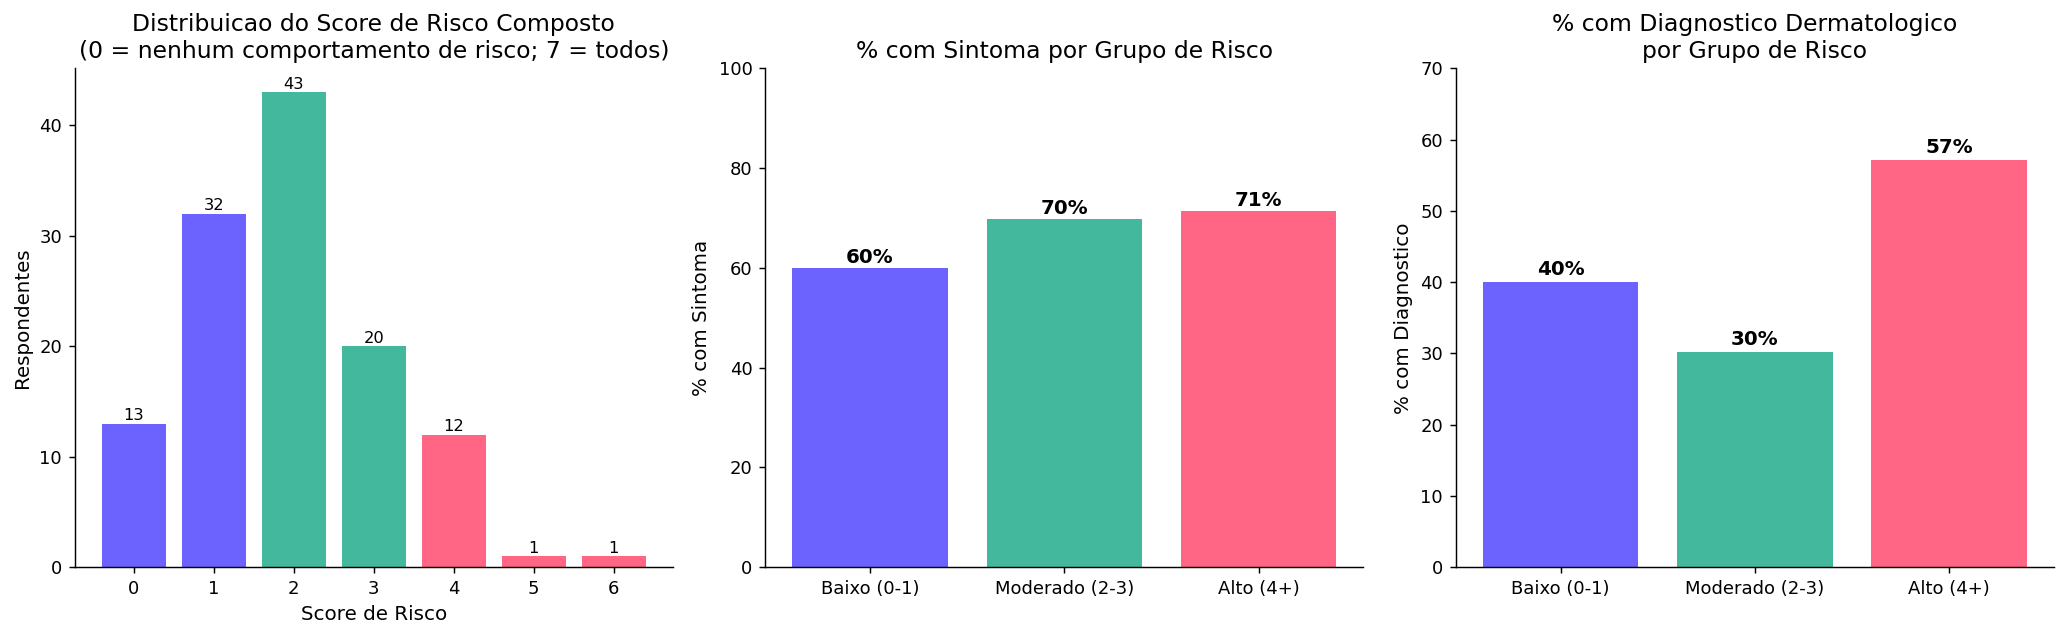


Perfil medio por grupo de risco:
risk_group               Baixo (0-1)  Moderado (2-3)  Alto (4+)
Automedicacao                   0.40            0.76       0.86
Sobreposicao Ativo              0.00            0.13       0.50
Crenca Natural                  0.07            0.43       0.79
Nao Sabe Combo                  0.11            0.32       0.50
Continua Uso c/ Sintoma         0.02            0.19       0.50
Metodo Nao Conv.                0.09            0.40       0.79
Uso Alto (6+ prod.)             0.02            0.10       0.29
Teve Sintoma                    0.60            0.70       0.71
Tem Diagnostico                 0.40            0.30       0.57
Media Ativos                    3.42            3.40       3.29
Media Qtd Produtos              1.58            1.70       2.00


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribuicao do score
score_vc = df['risk_score'].value_counts().sort_index()
axes[0].bar(score_vc.index, score_vc.values,
            color=[PALETTE[0] if v<=1 else PALETTE[2] if v<=3 else PALETTE[1] for v in score_vc.index])
axes[0].set_title('Distribuicao do Score de Risco Composto\n(0 = nenhum comportamento de risco; 7 = todos)')
axes[0].set_xlabel('Score de Risco')
axes[0].set_ylabel('Respondentes')
for bar, v in zip(axes[0].patches, score_vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, str(v), ha='center', fontsize=9)

# Sintoma por grupo de risco
rg_sint = df.groupby('risk_group')['teve_sintoma'].mean()*100
axes[1].bar(rg_sint.index, rg_sint.values, color=[PALETTE[0], PALETTE[2], PALETTE[1]])
axes[1].set_title('% com Sintoma por Grupo de Risco')
axes[1].set_ylabel('% com Sintoma')
axes[1].set_ylim(0, 100)
for bar, v in zip(axes[1].patches, rg_sint.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')

# Diagnostico por grupo de risco
rg_diag = df.groupby('risk_group')['tem_diagnostico'].mean()*100
axes[2].bar(rg_diag.index, rg_diag.values, color=[PALETTE[0], PALETTE[2], PALETTE[1]])
axes[2].set_title('% com Diagnostico Dermatologico\npor Grupo de Risco')
axes[2].set_ylabel('% com Diagnostico')
axes[2].set_ylim(0, 70)
for bar, v in zip(axes[2].patches, rg_diag.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Tabela de perfil por grupo
feat_group = ['automedicacao_bin','sobreposicao_bin','crenca_natural_bin',
              'nao_sei_combo','continua_uso','metodo_nao_conv','uso_alto',
              'teve_sintoma','tem_diagnostico','n_ativos','num_produtos_ord']
labels = ['Automedicacao','Sobreposicao Ativo','Crenca Natural',
          'Nao Sabe Combo','Continua Uso c/ Sintoma','Metodo Nao Conv.',
          'Uso Alto (6+ prod.)','Teve Sintoma','Tem Diagnostico',
          'Media Ativos','Media Qtd Produtos']
summary = df.groupby('risk_group')[feat_group].mean().T
summary.index = labels
print("\nPerfil medio por grupo de risco:")
print(summary.round(2).to_string())


## 3. Random Forest — Predição de Sintoma e Importância de Features

Random Forest (5-fold CV):
  AUC  = 0.680 +/- 0.092
  ACC  = 0.632 +/- 0.069
  F1   = 0.719 +/- 0.057


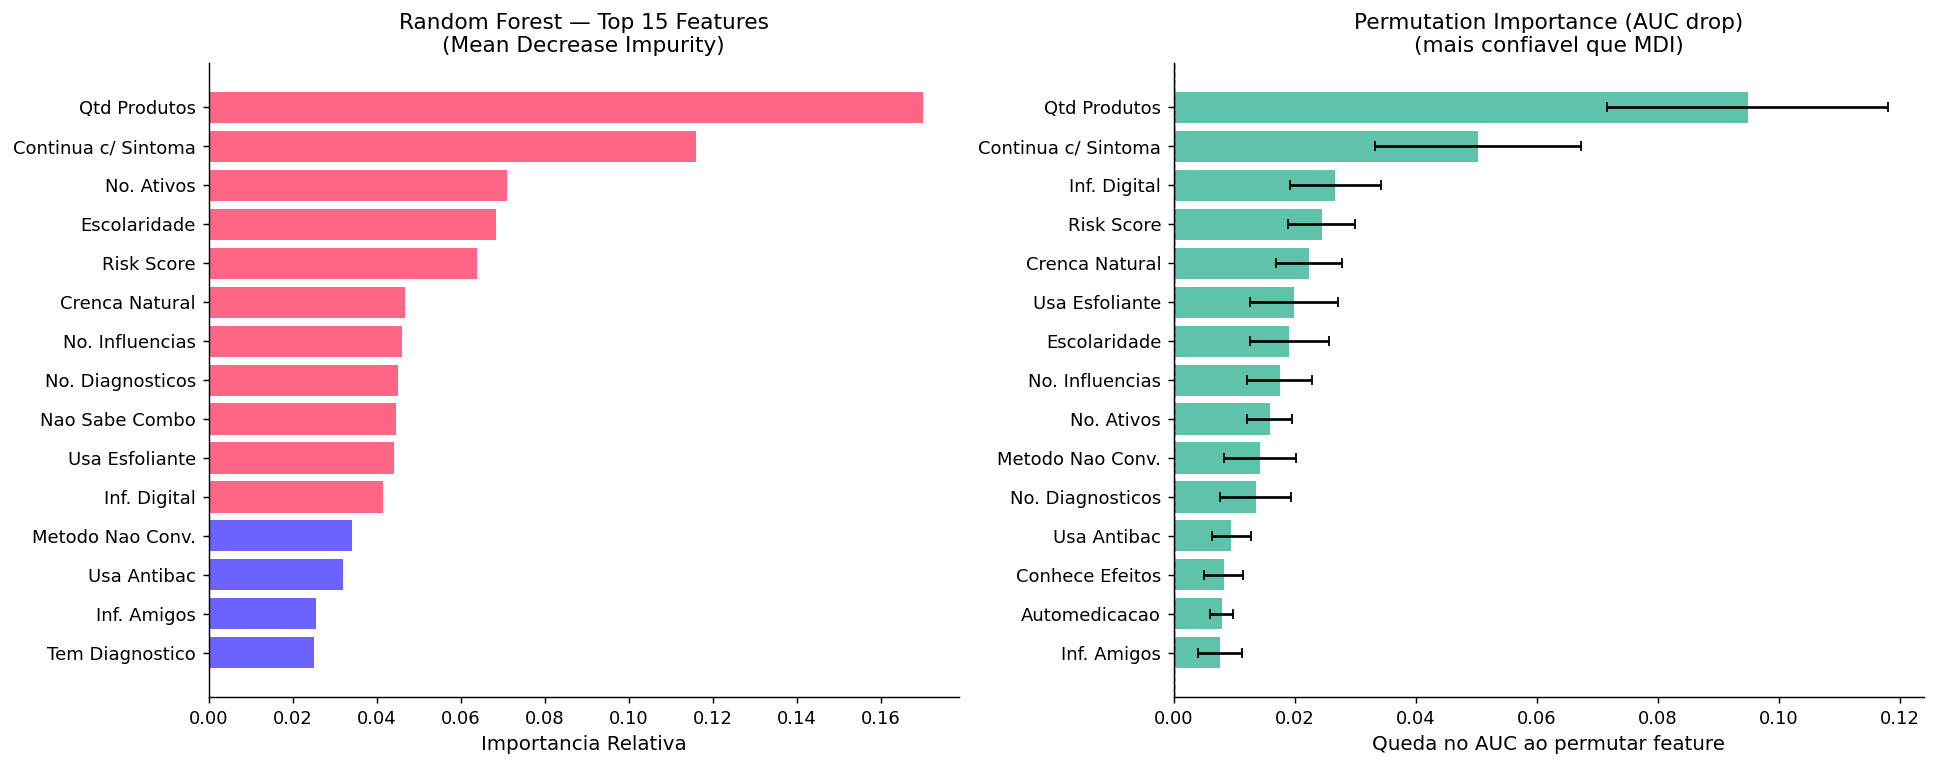


Top 5 por Permutation Importance:
  Qtd Produtos: 0.0949 +/- 0.0232
  Continua c/ Sintoma: 0.0503 +/- 0.0170
  Inf. Digital: 0.0267 +/- 0.0076
  Risk Score: 0.0244 +/- 0.0055
  Crenca Natural: 0.0223 +/- 0.0055


In [4]:
FEATURES = [
    'num_produtos_ord','n_ativos','escolaridade_ord','automedicacao_bin',
    'sobreposicao_bin','conhece_bin','crenca_natural_bin','genero_bin',
    'nao_sei_combo','continua_uso','metodo_nao_conv','risk_score',
    'n_influencias','inf_digital','inf_profissional','inf_amigos',
    'usa_acido','usa_retinoide','usa_esfoliante','usa_antibac',
    'tem_diagnostico','n_diagnosticos'
]
FEAT_LABELS = [
    'Qtd Produtos','No. Ativos','Escolaridade','Automedicacao',
    'Sobreposicao Ativo','Conhece Efeitos','Crenca Natural','Genero (Fem)',
    'Nao Sabe Combo','Continua c/ Sintoma','Metodo Nao Conv.','Risk Score',
    'No. Influencias','Inf. Digital','Inf. Profissional','Inf. Amigos',
    'Usa Acido','Usa Retinoide','Usa Esfoliante','Usa Antibac',
    'Tem Diagnostico','No. Diagnosticos'
]

dfm = df[FEATURES + ['teve_sintoma']].dropna()
X = dfm[FEATURES].values
y = dfm['teve_sintoma'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=5,
                             min_samples_leaf=3, random_state=42,
                             class_weight='balanced')
rf_auc  = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
rf_acc  = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
rf_f1   = cross_val_score(rf, X, y, cv=cv, scoring='f1')

rf.fit(X, y)

print(f"Random Forest (5-fold CV):")
print(f"  AUC  = {rf_auc.mean():.3f} +/- {rf_auc.std():.3f}")
print(f"  ACC  = {rf_acc.mean():.3f} +/- {rf_acc.std():.3f}")
print(f"  F1   = {rf_f1.mean():.3f} +/- {rf_f1.std():.3f}")

# Feature importances
imp = rf.feature_importances_
idx = np.argsort(imp)
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Importancia (MDI)
colors_imp = [PALETTE[1] if imp[i] > np.median(imp) else PALETTE[0] for i in idx[-top_n:]]
axes[0].barh([FEAT_LABELS[i] for i in idx[-top_n:]],
             imp[idx[-top_n:]], color=colors_imp)
axes[0].set_title(f'Random Forest — Top {top_n} Features\n(Mean Decrease Impurity)', fontsize=12)
axes[0].set_xlabel('Importancia Relativa')

# Permutation importance
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42,
                               scoring='roc_auc')
perm_mean = perm.importances_mean
perm_std  = perm.importances_std
pidx = np.argsort(perm_mean)
axes[1].barh([FEAT_LABELS[i] for i in pidx[-top_n:]],
             perm_mean[pidx[-top_n:]],
             xerr=perm_std[pidx[-top_n:]],
             color=PALETTE[2], capsize=3, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title(f'Permutation Importance (AUC drop)\n(mais confiavel que MDI)', fontsize=12)
axes[1].set_xlabel('Queda no AUC ao permutar feature')

plt.tight_layout()
plt.show()

print("\nTop 5 por Permutation Importance:")
for i in pidx[::-1][:5]:
    print(f"  {FEAT_LABELS[i]}: {perm_mean[i]:.4f} +/- {perm_std[i]:.4f}")


## 4. SHAP Values — Explicabilidade do Random Forest

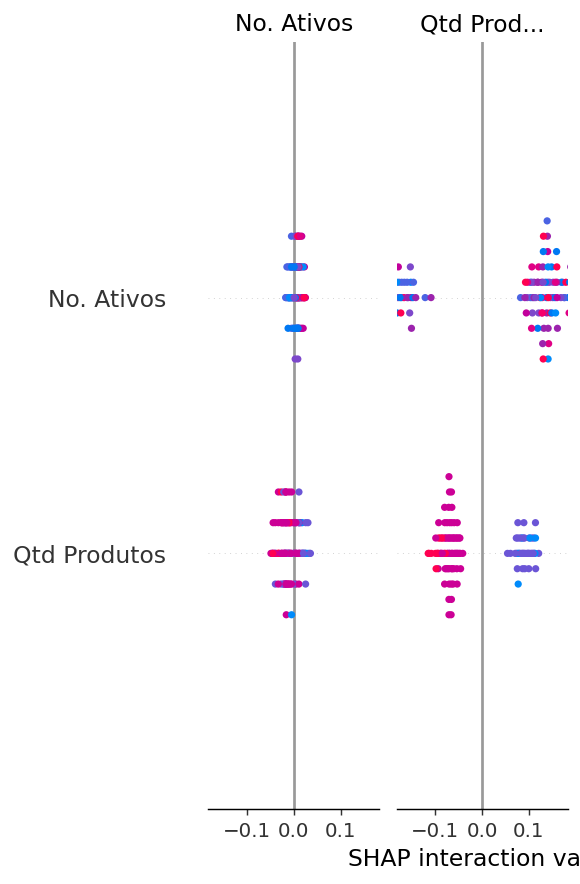

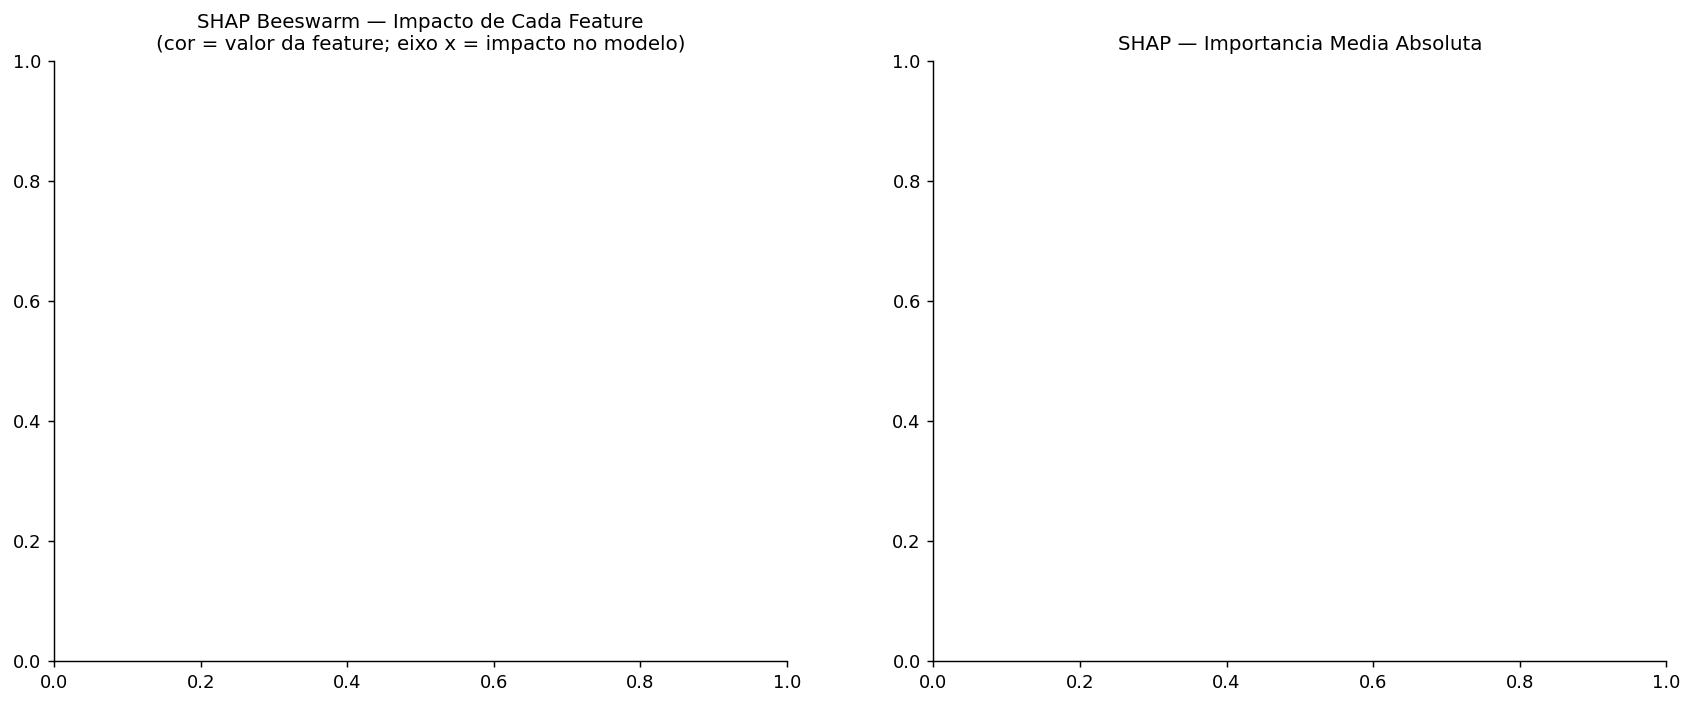

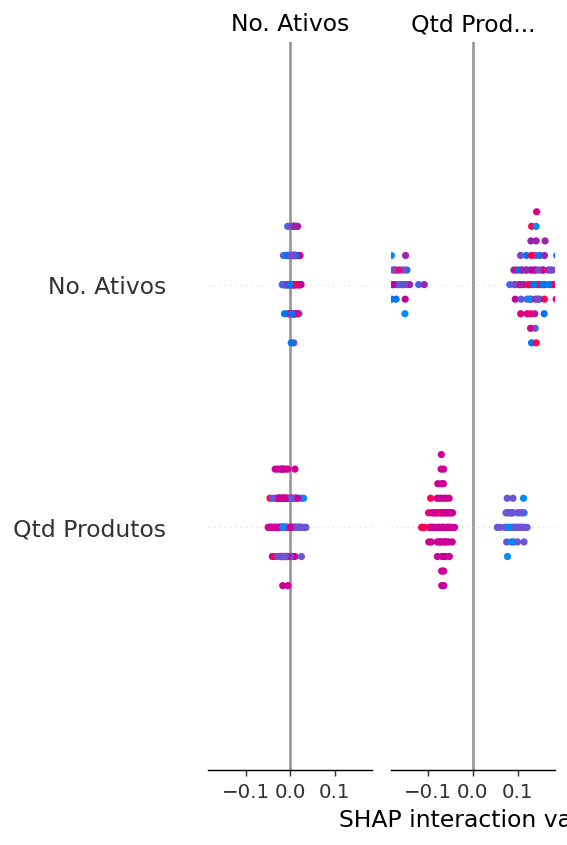

SHAP calculado. Interpretacao:
  - Valores positivos = aumentam probabilidade de ter sintoma
  - Valores negativos = reduzem probabilidade de ter sintoma
  - Cor vermelha = valor alto da feature; azul = valor baixo


In [5]:
if SHAP_OK:
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X)

    # Para classificacao binaria, pega classe 1
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Beeswarm plot (summary)
    plt.sca(axes[0])
    shap.summary_plot(sv, X, feature_names=FEAT_LABELS,
                      show=False, plot_size=None, color_bar=True)
    axes[0].set_title('SHAP Beeswarm — Impacto de Cada Feature\n(cor = valor da feature; eixo x = impacto no modelo)', fontsize=11)

    # Bar plot medio
    plt.sca(axes[1])
    shap.summary_plot(sv, X, feature_names=FEAT_LABELS,
                      plot_type='bar', show=False, plot_size=None)
    axes[1].set_title('SHAP — Importancia Media Absoluta', fontsize=11)

    plt.tight_layout()
    plt.savefig('/tmp/shap_plot.png', bbox_inches='tight', dpi=130)
    plt.show()
    print("SHAP calculado. Interpretacao:")
    print("  - Valores positivos = aumentam probabilidade de ter sintoma")
    print("  - Valores negativos = reduzem probabilidade de ter sintoma")
    print("  - Cor vermelha = valor alto da feature; azul = valor baixo")
else:
    print("SHAP nao disponivel. Instale com: pip install shap")


## 5. Comparação de Modelos — Random Forest vs Naive Bayes vs Gradient Boosting vs SVM

Comparacao de Modelos (5-fold CV):
                              AUC           ACC            F1          Prec           Rec
Random Forest        0.680 ±0.092  0.632 ±0.069  0.719 ±0.057  0.729 ±0.055  0.717 ±0.090
Gradient Boosting    0.657 ±0.093  0.599 ±0.041  0.698 ±0.040  0.701 ±0.044  0.705 ±0.093
Naive Bayes (Gauss)  0.748 ±0.061  0.517 ±0.060  0.428 ±0.113  0.978 ±0.044  0.285 ±0.111
Naive Bayes (Bern)   0.704 ±0.092  0.673 ±0.055  0.758 ±0.047  0.745 ±0.048  0.778 ±0.084
Logistic Reg.        0.697 ±0.074  0.583 ±0.088  0.646 ±0.096  0.728 ±0.069  0.594 ±0.150
SVM (RBF)            0.596 ±0.097  0.558 ±0.045  0.640 ±0.077  0.696 ±0.045  0.619 ±0.163
Decision Tree        0.646 ±0.094  0.567 ±0.108  0.616 ±0.117  0.728 ±0.093  0.557 ±0.192


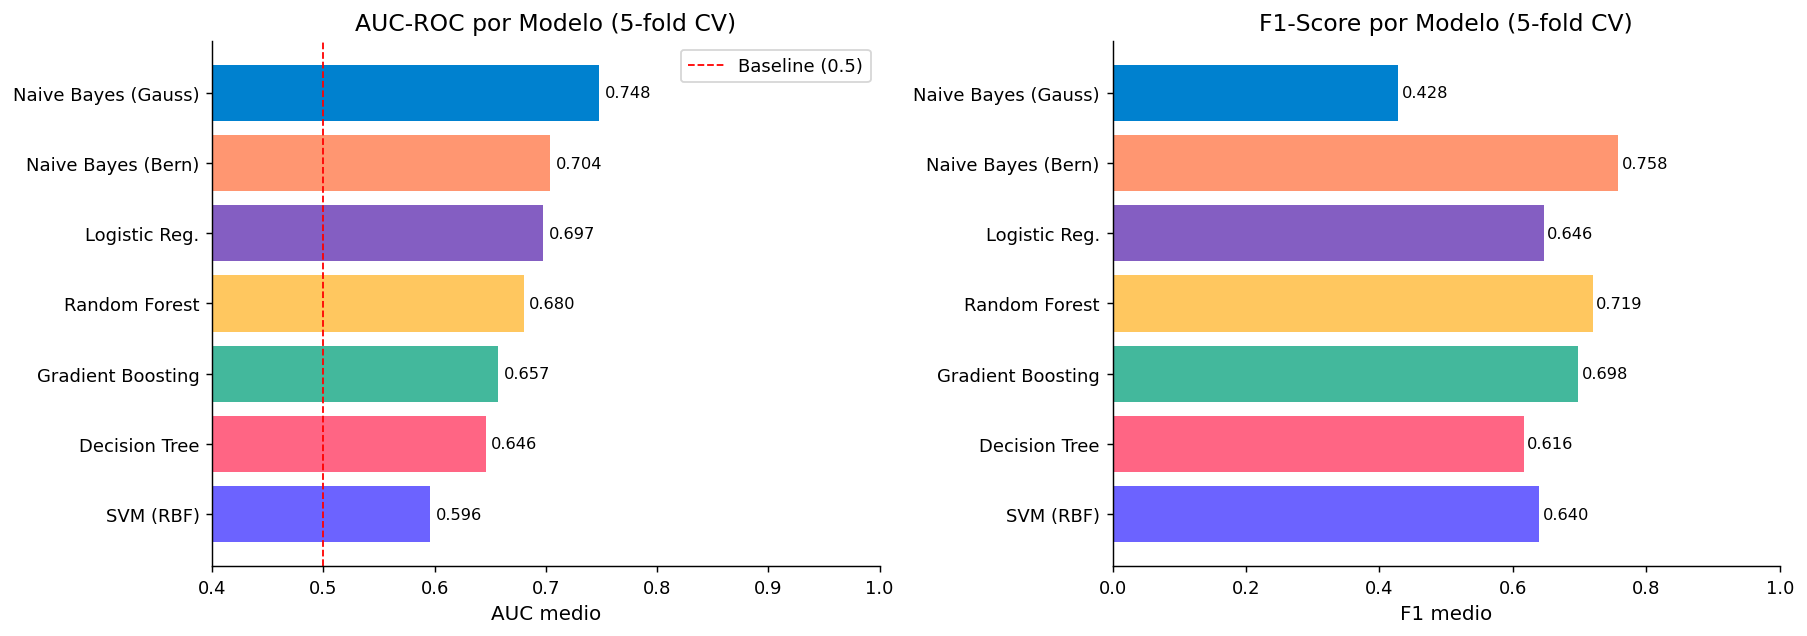

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

models = {
    'Random Forest':    RandomForestClassifier(n_estimators=300, max_depth=5,
                            min_samples_leaf=3, class_weight='balanced', random_state=42),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=200, max_depth=3,
                            learning_rate=0.05, random_state=42),
    'Naive Bayes (Gauss)': GaussianNB(),
    'Naive Bayes (Bern)':  BernoulliNB(alpha=1.0),
    'Logistic Reg.':    LogisticRegression(max_iter=1000, C=1.0,
                            class_weight='balanced', random_state=42),
    'SVM (RBF)':        SVC(kernel='rbf', probability=True,
                            class_weight='balanced', random_state=42),
    'Decision Tree':    DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                            class_weight='balanced', random_state=42),
}

results = {}
for name, model in models.items():
    Xin = X_sc if name in ['Logistic Reg.','SVM (RBF)','Naive Bayes (Gauss)','Naive Bayes (Bern)'] else X
    cv_res = cross_validate(model, Xin, y, cv=cv,
                            scoring=['roc_auc','accuracy','f1','precision','recall'],
                            return_train_score=False)
    results[name] = {
        'AUC':  f"{cv_res['test_roc_auc'].mean():.3f} ±{cv_res['test_roc_auc'].std():.3f}",
        'ACC':  f"{cv_res['test_accuracy'].mean():.3f} ±{cv_res['test_accuracy'].std():.3f}",
        'F1':   f"{cv_res['test_f1'].mean():.3f} ±{cv_res['test_f1'].std():.3f}",
        'Prec': f"{cv_res['test_precision'].mean():.3f} ±{cv_res['test_precision'].std():.3f}",
        'Rec':  f"{cv_res['test_recall'].mean():.3f} ±{cv_res['test_recall'].std():.3f}",
        '_auc_mean': cv_res['test_roc_auc'].mean(),
        '_f1_mean':  cv_res['test_f1'].mean(),
    }

res_df = pd.DataFrame(results).T.drop(columns=['_auc_mean','_f1_mean'])
print("Comparacao de Modelos (5-fold CV):")
print(res_df.to_string())

# Grafico comparativo
auc_vals = {k: v['_auc_mean'] for k, v in results.items()}
f1_vals  = {k: v['_f1_mean']  for k, v in results.items()}
sorted_names = sorted(auc_vals, key=auc_vals.get, reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_m = sns.color_palette(PALETTE, len(sorted_names))

axes[0].barh(sorted_names[::-1], [auc_vals[n] for n in sorted_names[::-1]], color=colors_m)
axes[0].axvline(0.5, color='red', lw=1, linestyle='--', label='Baseline (0.5)')
axes[0].set_title('AUC-ROC por Modelo (5-fold CV)')
axes[0].set_xlabel('AUC medio')
axes[0].set_xlim(0.4, 1.0)
axes[0].legend()
for bar, nm in zip(axes[0].patches, sorted_names[::-1]):
    axes[0].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{auc_vals[nm]:.3f}', va='center', fontsize=9)

axes[1].barh(sorted_names[::-1], [f1_vals[n] for n in sorted_names[::-1]], color=colors_m)
axes[1].set_title('F1-Score por Modelo (5-fold CV)')
axes[1].set_xlabel('F1 medio')
axes[1].set_xlim(0, 1.0)
for bar, nm in zip(axes[1].patches, sorted_names[::-1]):
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{f1_vals[nm]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 6. Curvas de Aprendizado — Overfitting e Capacidade Generalizativa

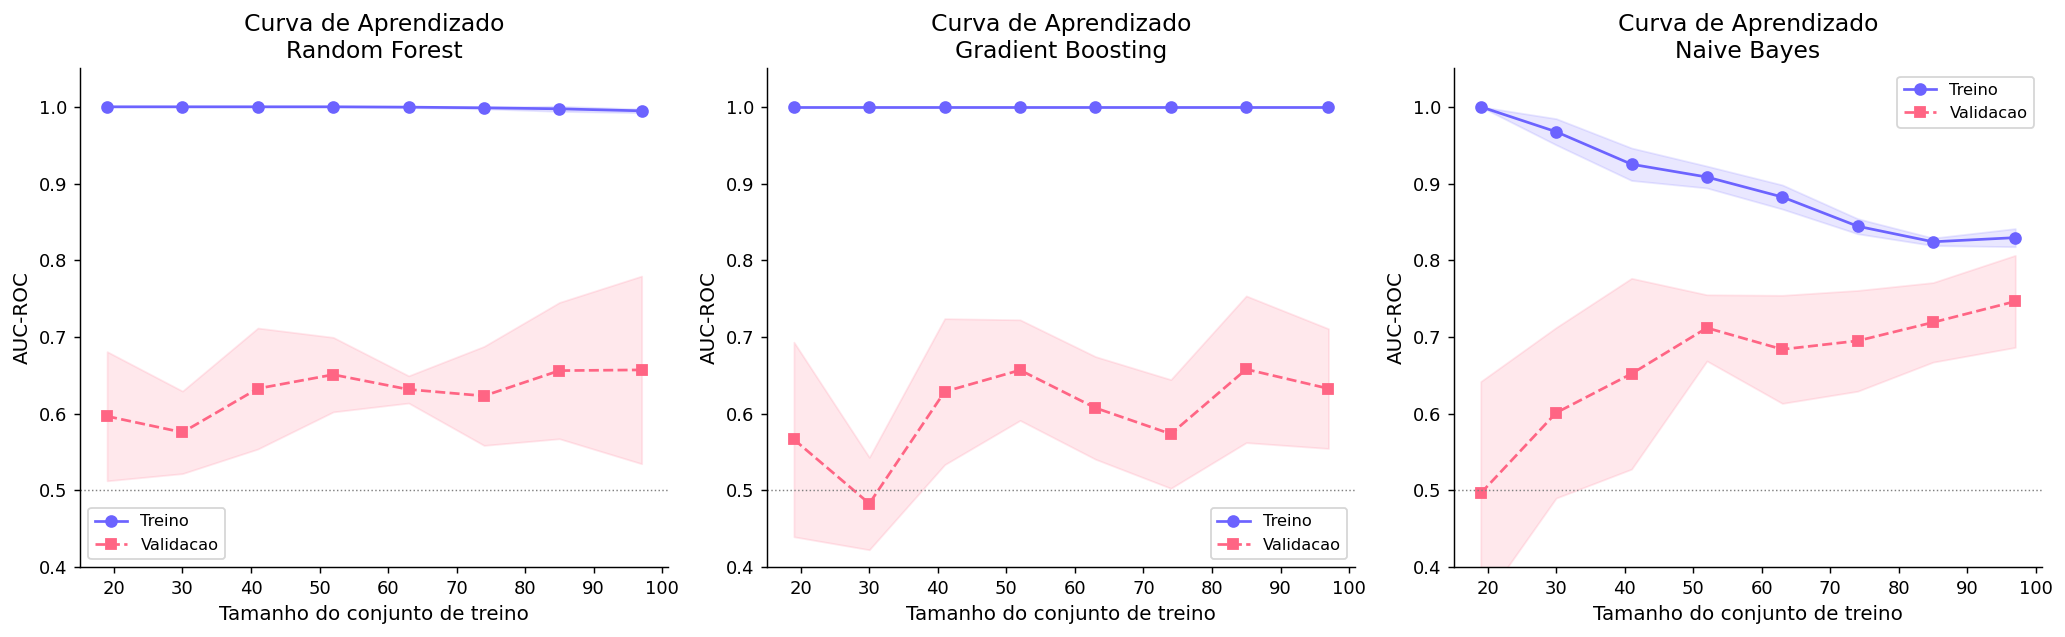

Interpretacao:
  - Gap grande entre treino e validacao = overfitting
  - Curvas convergindo = modelo generalizando bem
  - Curva de validacao estagnada com mais dados = limite da feature space


In [7]:
models_lc = {
    'Random Forest':     RandomForestClassifier(n_estimators=200, max_depth=5,
                             class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3,
                             learning_rate=0.1, random_state=42),
    'Naive Bayes':       GaussianNB(),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring='roc_auc',
        train_sizes=np.linspace(0.2, 1.0, 8),
        random_state=42, n_jobs=-1)
    t_mean = train_scores.mean(axis=1)
    t_std  = train_scores.std(axis=1)
    v_mean = val_scores.mean(axis=1)
    v_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, t_mean, 'o-', color=PALETTE[0], label='Treino')
    ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color=PALETTE[0])
    ax.plot(train_sizes, v_mean, 's--', color=PALETTE[1], label='Validacao')
    ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color=PALETTE[1])
    ax.set_title(f'Curva de Aprendizado\n{name}')
    ax.set_xlabel('Tamanho do conjunto de treino')
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=9)
    ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')

plt.tight_layout()
plt.show()

print("Interpretacao:")
print("  - Gap grande entre treino e validacao = overfitting")
print("  - Curvas convergindo = modelo generalizando bem")
print("  - Curva de validacao estagnada com mais dados = limite da feature space")


## 7. Curvas ROC e Precision-Recall — Todos os Modelos

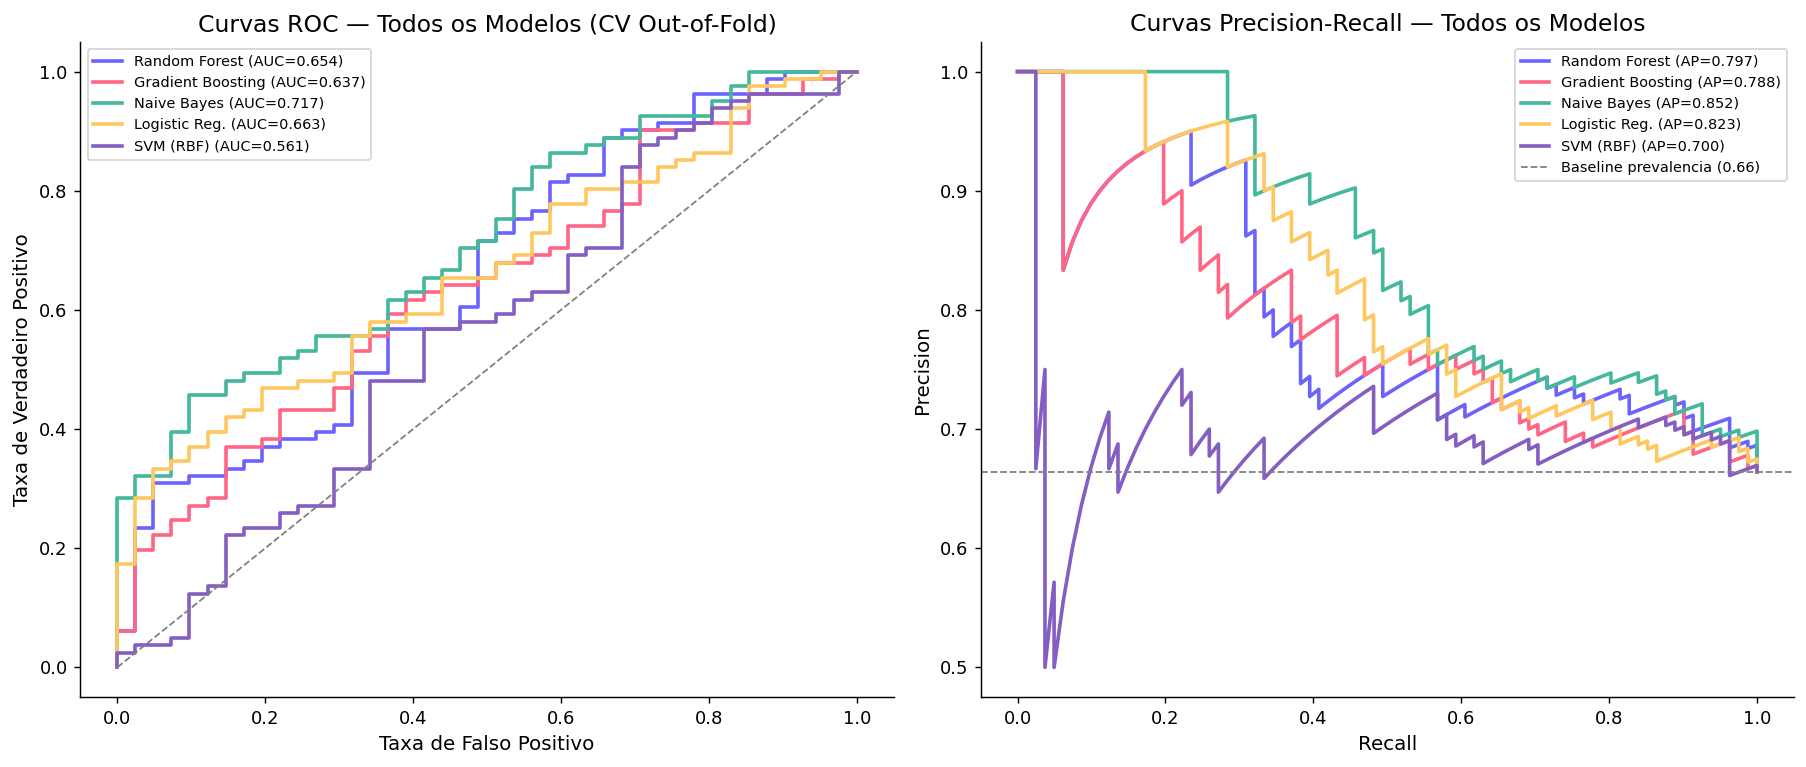

In [8]:
from sklearn.model_selection import StratifiedKFold

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_list = [
    ('Random Forest',     RandomForestClassifier(n_estimators=300, max_depth=5,
                              class_weight='balanced', random_state=42), X),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, max_depth=3,
                              learning_rate=0.05, random_state=42), X),
    ('Naive Bayes',       GaussianNB(), X_sc),
    ('Logistic Reg.',     LogisticRegression(max_iter=1000, class_weight='balanced',
                              random_state=42), X_sc),
    ('SVM (RBF)',         SVC(kernel='rbf', probability=True,
                              class_weight='balanced', random_state=42), X_sc),
]

for (name, model, Xin), color in zip(model_list, PALETTE):
    y_prob = np.zeros(len(y))
    for tr, te in cv.split(Xin, y):
        model.fit(Xin[tr], y[tr])
        y_prob[te] = model.predict_proba(Xin[te])[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc_val = roc_auc_score(y, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={auc_val:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y, y_prob)
    ap = average_precision_score(y, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{name} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].set_title('Curvas ROC — Todos os Modelos (CV Out-of-Fold)')
axes[0].legend(fontsize=8)

baseline_prev = y.mean()
axes[1].axhline(baseline_prev, color='gray', lw=1, linestyle='--',
                label=f'Baseline prevalencia ({baseline_prev:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall — Todos os Modelos')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 8. Naive Bayes — Probabilidades Posteriores por Perfil

Probabilidade Posterior de ter Sintoma (Naive Bayes):
------------------------------------------------------------
  Risco Baixo (rotina simples, sem automedicacao): 0.0%
  Risco Moderado (3-5 prod, automedicacao, nao sabe combo: 0.0%
  Risco Alto (uso intensivo, sobreposicao, crenca natural: 100.0%
  Perfil Tipico da Amostra (media): 0.0%


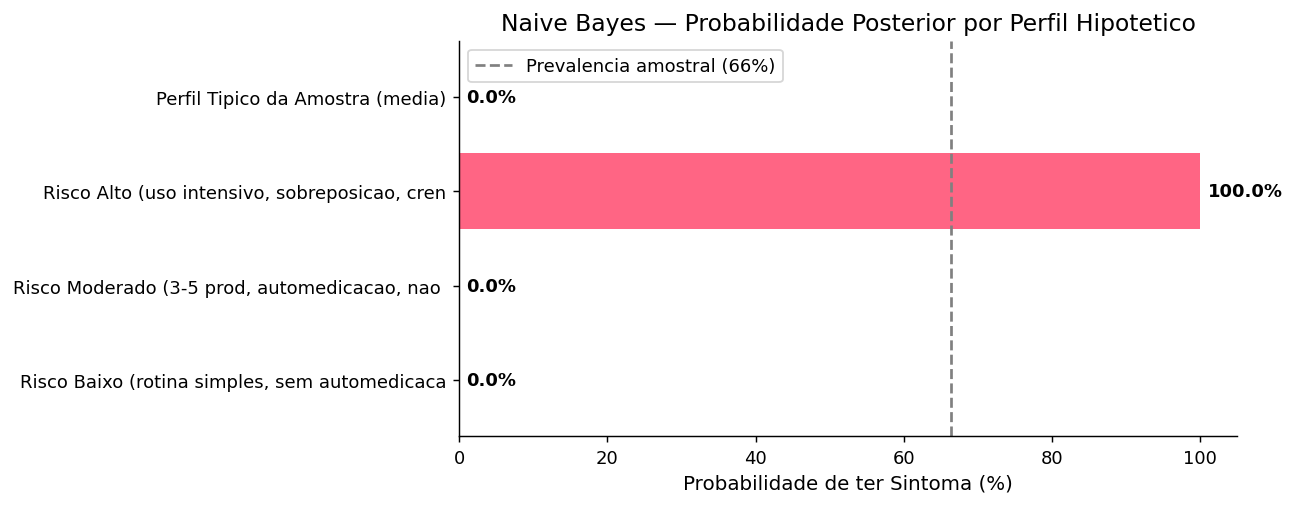


Log-likelihood ratio (Naive Bayes) — impacto de cada feature:
            Feature      LLR
       Qtd Produtos 0.809591
Continua c/ Sintoma 0.666945
       Inf. Digital 0.339670
     Usa Esfoliante 0.330421
       Escolaridade 0.324829
   No. Diagnosticos 0.318298
    Tem Diagnostico 0.313912
   Metodo Nao Conv. 0.269404
         No. Ativos 0.256029
          Usa Acido 0.241929


In [9]:
# Treina NB no conjunto completo para interpretacao
nb_model = GaussianNB()
nb_model.fit(X_sc, y)

# Probabilidade posterior para perfis hipoteticos
perfis = {
    'Risco Baixo (rotina simples, sem automedicacao)':
        [1, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0],
    'Risco Moderado (3-5 prod, automedicacao, nao sabe combo)':
        [2, 3, 2, 1, 0, 1, 0, 1, 1, 0, 0, 3, 3, 1, 1, 1, 1, 0, 1, 0, 0, 0],
    'Risco Alto (uso intensivo, sobreposicao, crenca natural)':
        [3, 5, 2, 1, 1, 0, 1, 1, 1, 1, 1, 6, 4, 1, 0, 1, 1, 1, 1, 1, 1, 2],
    'Perfil Tipico da Amostra (media)':
        list(np.round(dfm[FEATURES].mean().values).astype(int)),
}

print("Probabilidade Posterior de ter Sintoma (Naive Bayes):")
print("-" * 60)
probs_perfil = []
for nome, feat_vals in perfis.items():
    fv = np.array(feat_vals).reshape(1, -1)
    fv_sc = scaler.transform(fv)
    prob = nb_model.predict_proba(fv_sc)[0, 1]
    probs_perfil.append((nome, prob))
    print(f"  {nome[:55]}: {prob*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
nomes = [p[0][:45] for p in probs_perfil]
probs = [p[1]*100 for p in probs_perfil]
cores = [PALETTE[0], PALETTE[2], PALETTE[1], PALETTE[3]]
bars = ax.barh(nomes, probs, color=cores)
ax.axvline(y.mean()*100, color='gray', lw=1.5, linestyle='--',
           label=f'Prevalencia amostral ({y.mean()*100:.0f}%)')
ax.set_xlabel('Probabilidade de ter Sintoma (%)')
ax.set_title('Naive Bayes — Probabilidade Posterior por Perfil Hipotetico')
ax.legend()
ax.set_xlim(0, 105)
for bar, v in zip(bars, probs):
    ax.text(v+1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Probabilidades por feature individual (log-likelihood ratio)
print("\nLog-likelihood ratio (Naive Bayes) — impacto de cada feature:")
theta_pos = nb_model.theta_[1]
theta_neg = nb_model.theta_[0]
llr = theta_pos - theta_neg
llr_df = pd.DataFrame({'Feature': FEAT_LABELS, 'LLR': llr}).sort_values('LLR', ascending=False)
print(llr_df[['Feature','LLR']].head(10).to_string(index=False))


## 9. Árvore de Decisão Interpretável — Regras de Classificação

Decision Tree AUC (CV): 0.646


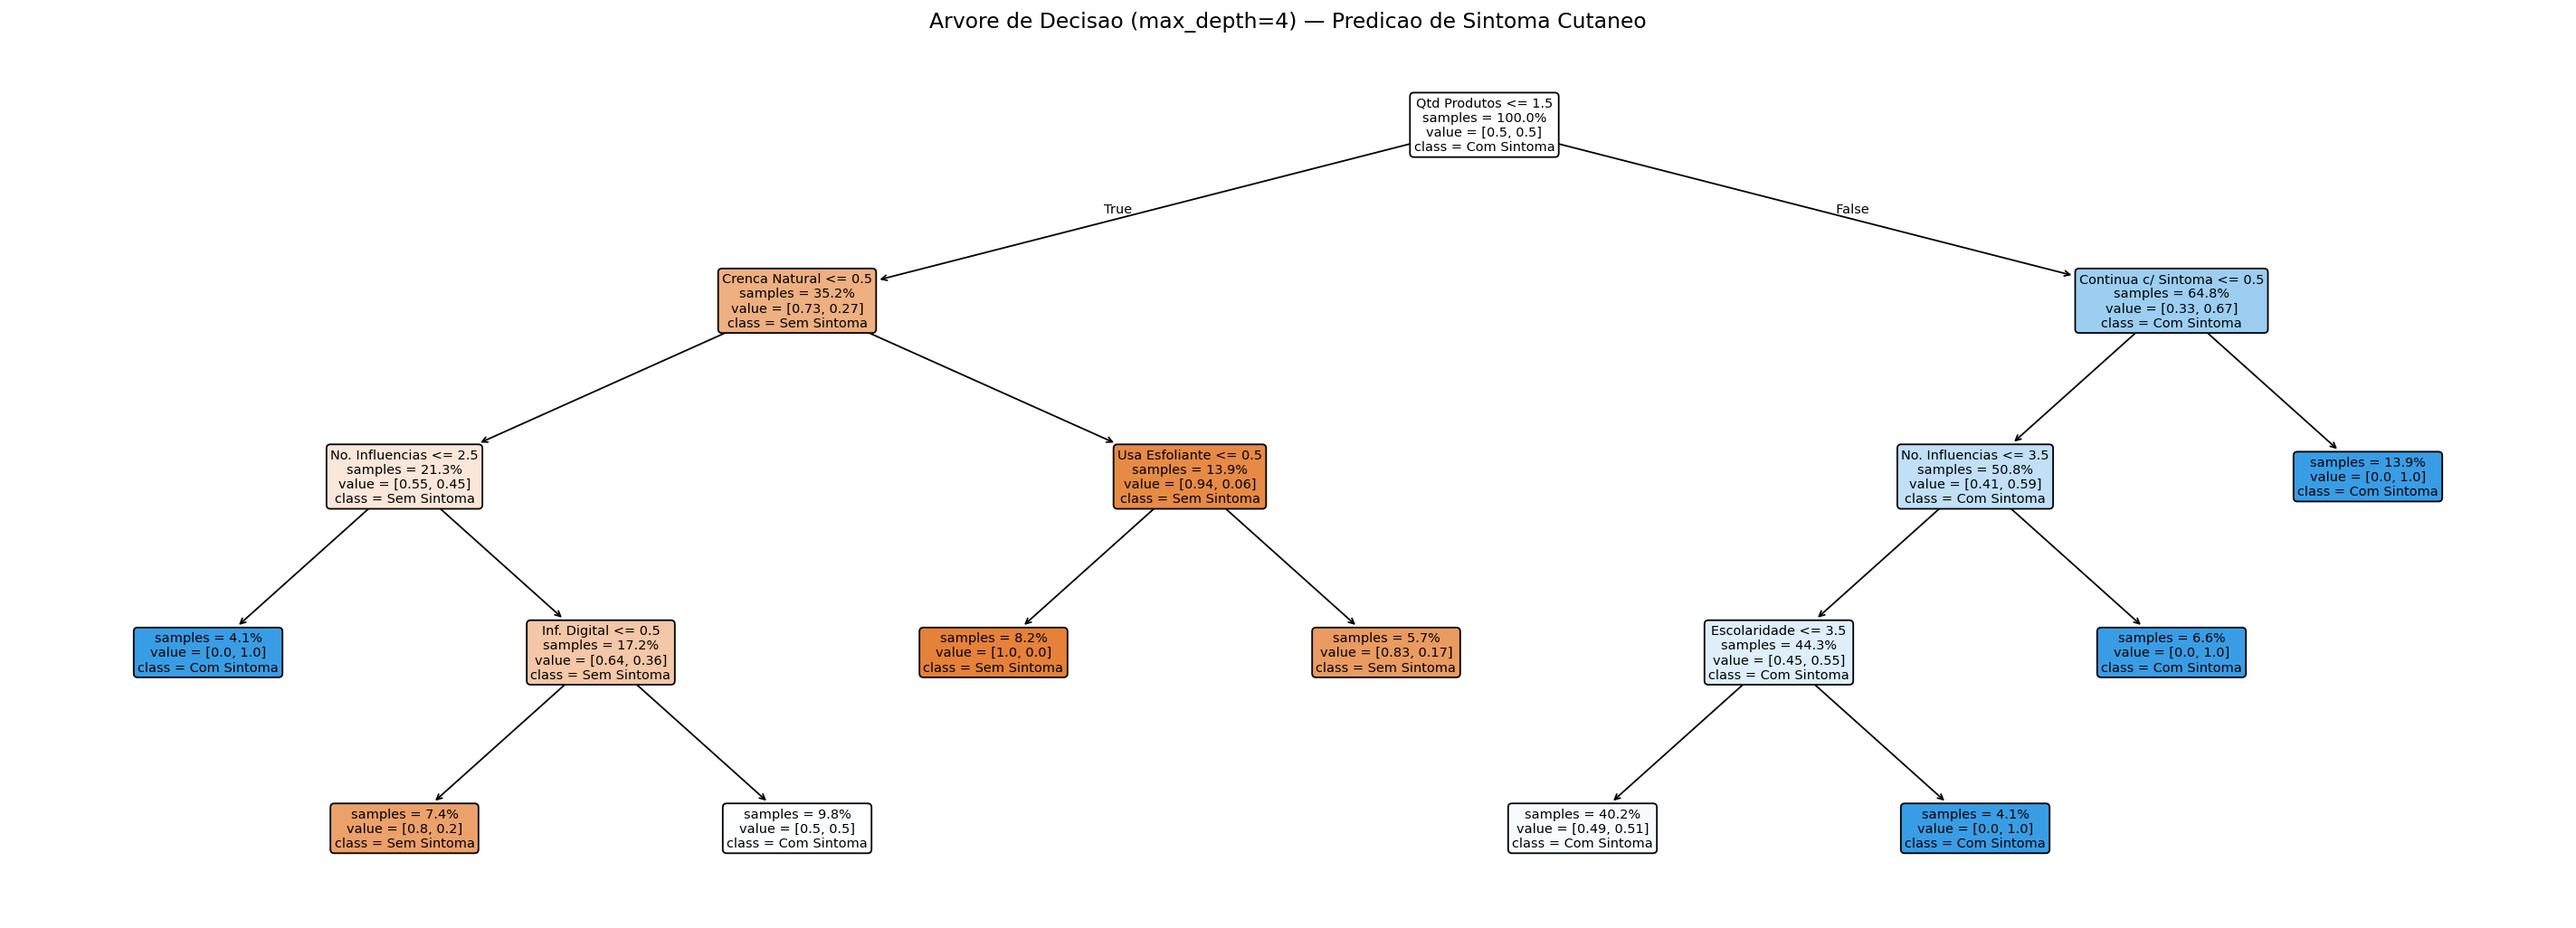


--- REGRAS DA ARVORE (primeiros 50 nos) ---
|--- Qtd Produtos <= 1.50
|   |--- Crenca Natural <= 0.50
|   |   |--- No. Influencias <= 2.50
|   |   |   |--- class: 1
|   |   |--- No. Influencias >  2.50
|   |   |   |--- Inf. Digital <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Inf. Digital >  0.50
|   |   |   |   |--- class: 1
|   |--- Crenca Natural >  0.50
|   |   |--- Usa Esfoliante <= 0.50
|   |   |   |--- class: 0
|   |   |--- Usa Esfoliante >  0.50
|   |   |   |--- class: 0
|--- Qtd Produtos >  1.50
|   |--- Continua c/ Sintoma <= 0.50
|   |   |--- No. Influencias <= 3.50
|   |   |   |--- Escolaridade <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- Escolaridade >  3.50
|   |   |   |   |--- class: 1
|   |   |--- No. Influencias >  3.50
|   |   |   |--- class: 1
|   |--- Continua c/ Sintoma >  0.50
|   |   |--- class: 1



In [10]:
from sklearn.tree import plot_tree

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                              class_weight='balanced', random_state=42)
dt.fit(X, y)

dt_auc = cross_val_score(dt, X, y, cv=cv, scoring='roc_auc').mean()
print(f"Decision Tree AUC (CV): {dt_auc:.3f}")

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, feature_names=FEAT_LABELS,
          class_names=['Sem Sintoma','Com Sintoma'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True,
          precision=2)
ax.set_title('Arvore de Decisao (max_depth=4) — Predicao de Sintoma Cutaneo', fontsize=13)
plt.tight_layout()
plt.show()

# Regras em texto
rules = export_text(dt, feature_names=FEAT_LABELS)
print("\n--- REGRAS DA ARVORE (primeiros 50 nos) ---")
for line in rules.split('\n')[:50]:
    print(line)


## 10. Regras de Associação (Apriori) — Padrões de Comportamento

Total de regras geradas (lift >= 1.2, suporte >= 15%): 128

Top regras com consequente = Sintoma ou Diagnostico:
  [Automedicacao, Usa_Esfoliante] => [Teve_Sintoma, Usa_Acido]
    suporte=0.22 | confianca=0.69 | lift=1.59
  [Usa_Acido] => [Teve_Sintoma, Automedicacao, Usa_Esfoliante]
    suporte=0.22 | confianca=0.36 | lift=1.51
  [Inf_Digital, Usa_Acido] => [Teve_Sintoma, Usa_Esfoliante]
    suporte=0.20 | confianca=0.53 | lift=1.51
  [Continua_Uso_Sintoma] => [Teve_Sintoma]
    suporte=0.16 | confianca=1.00 | lift=1.51
  [Inf_Digital, Usa_Esfoliante] => [Teve_Sintoma, Usa_Acido]
    suporte=0.20 | confianca=0.65 | lift=1.49
  [Usa_Esfoliante] => [Inf_Digital, Teve_Sintoma, Usa_Acido]
    suporte=0.20 | confianca=0.41 | lift=1.48
  [Usa_Esfoliante] => [Teve_Sintoma, Automedicacao, Usa_Acido]
    suporte=0.22 | confianca=0.47 | lift=1.46
  [Automedicacao, Usa_Acido] => [Teve_Sintoma, Usa_Esfoliante]
    suporte=0.22 | confianca=0.50 | lift=1.42
  [Usa_Acido, Usa_Esfoliante] => [Teve_Si

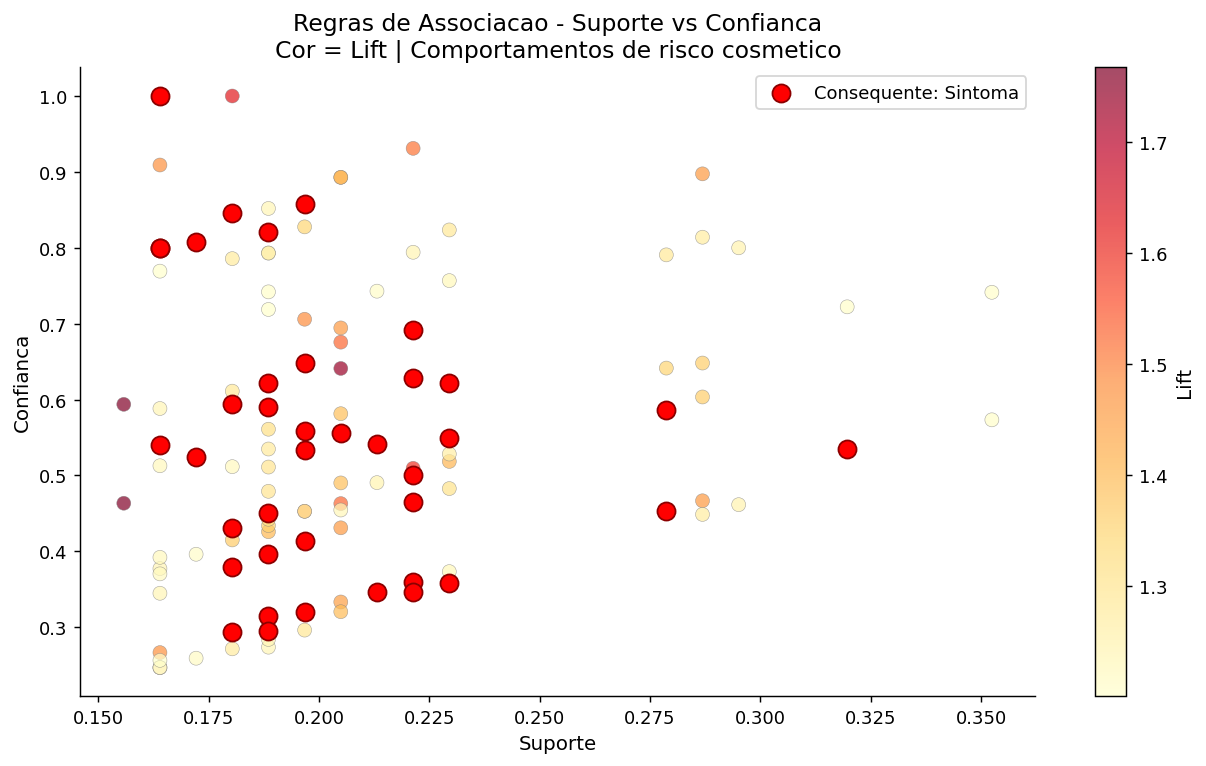

In [11]:
if MLXTEND_OK:
    # Codifica comportamentos como transacoes binarias
    comportamentos = {
        'Automedicacao': df['automedicacao_bin'],
        'Sobreposicao_Ativo': df['sobreposicao_bin'],
        'Crenca_Natural': df['crenca_natural_bin'],
        'Nao_Sabe_Combo': df['nao_sei_combo'],
        'Continua_Uso_Sintoma': df['continua_uso'],
        'Uso_Alto_6plus': df['uso_alto'],
        'Teve_Sintoma': df['teve_sintoma'],
        'Tem_Diagnostico': df['tem_diagnostico'],
        'Usa_Acido': df['usa_acido'],
        'Usa_Esfoliante': df['usa_esfoliante'],
        'Usa_Retinoide': df['usa_retinoide'],
        'Inf_Digital': df['inf_digital'],
        'Inf_Amigos': df['inf_amigos'],
        'Metodo_Nao_Conv': df['metodo_nao_conv'],
    }
    basket = pd.DataFrame(comportamentos).dropna().astype(bool)

    freq_items = apriori(basket, min_support=0.15, use_colnames=True, max_len=4)
    rules_df = association_rules(freq_items, metric='lift', min_threshold=1.2,
                                 num_itemsets=len(freq_items))
    rules_df = rules_df.sort_values('lift', ascending=False)

    print(f"Total de regras geradas (lift >= 1.2, suporte >= 15%): {len(rules_df)}")

    # Filtra regras com antecedente -> Teve_Sintoma ou Tem_Diagnostico
    target_rules = rules_df[
        rules_df['consequents'].apply(lambda x: 'Teve_Sintoma' in x or 'Tem_Diagnostico' in x)
    ].head(15)

    print("\nTop regras com consequente = Sintoma ou Diagnostico:")
    for _, row in target_rules.iterrows():
        ant = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        print(f"  [{ant}] => [{cons}]")
        print(f"    suporte={row['support']:.2f} | confianca={row['confidence']:.2f} | lift={row['lift']:.2f}")

    # Grafico scatter lift vs confianca
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(rules_df['support'], rules_df['confidence'],
                         c=rules_df['lift'], cmap='YlOrRd',
                         alpha=0.7, s=60, edgecolors='gray', lw=0.3)
    plt.colorbar(scatter, ax=ax, label='Lift')
    ax.set_xlabel('Suporte')
    ax.set_ylabel('Confianca')
    ax.set_title('Regras de Associacao - Suporte vs Confianca\nCor = Lift | Comportamentos de risco cosmetico')

    # Destaca regras de sintoma
    symp_rules = rules_df[rules_df['consequents'].apply(lambda x: 'Teve_Sintoma' in x)]
    if len(symp_rules):
        ax.scatter(symp_rules['support'], symp_rules['confidence'],
                   color='red', s=100, zorder=5, label='Consequente: Sintoma',
                   edgecolors='darkred', lw=1)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mlxtend nao instalado. Execute: pip install mlxtend --break-system-packages")


## 11. Gradient Boosting — Matriz de Confusão e Threshold Otimizado

Gradient Boosting AUC (CV): 0.657 +/- 0.093


Threshold otimizado (Youden J): 0.792

Classification Report (threshold=0.79):
              precision    recall  f1-score   support

 Sem Sintoma       0.45      0.61      0.52        41
 Com Sintoma       0.76      0.62      0.68        81

    accuracy                           0.61       122
   macro avg       0.60      0.61      0.60       122
weighted avg       0.65      0.61      0.62       122



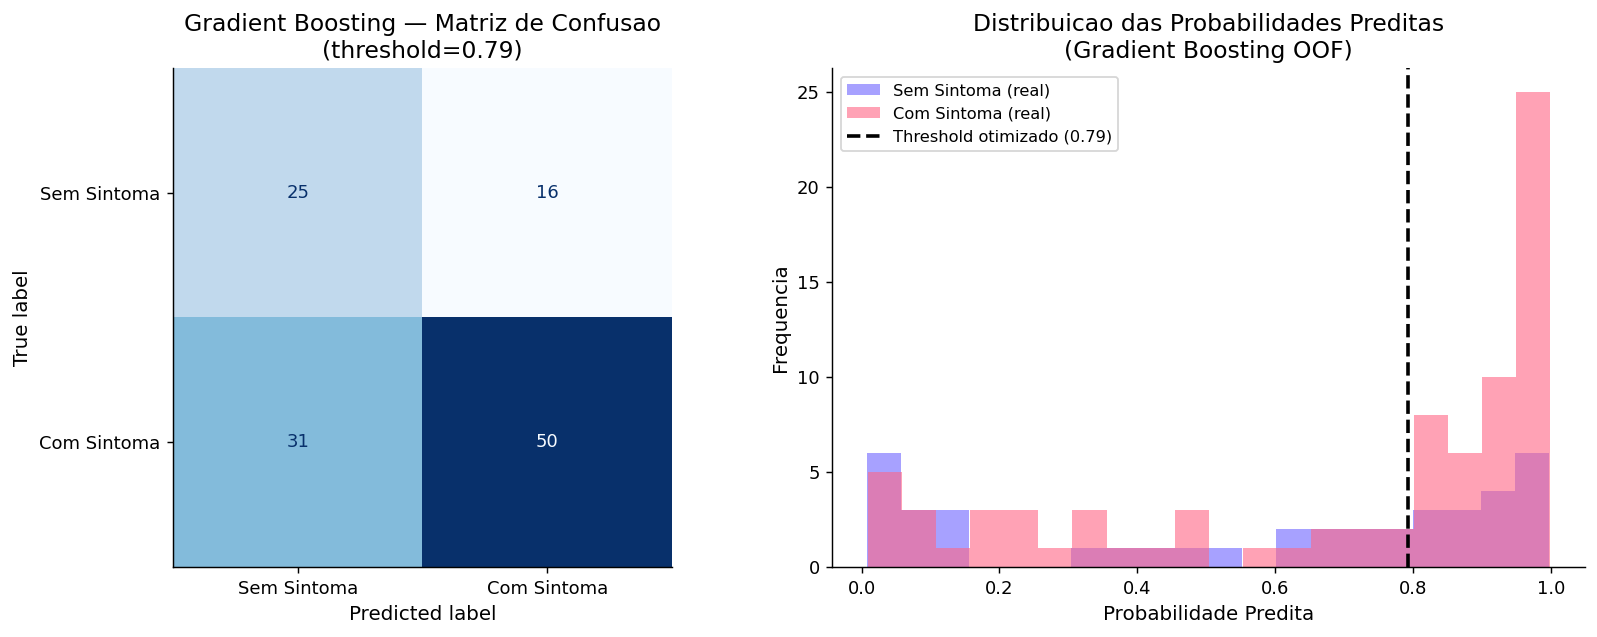

In [12]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                 learning_rate=0.05, random_state=42)
gb.fit(X, y)

gb_auc = cross_val_score(gb, X, y, cv=cv, scoring='roc_auc')
print(f"Gradient Boosting AUC (CV): {gb_auc.mean():.3f} +/- {gb_auc.std():.3f}")

# Out-of-fold predictions para threshold otimizado
y_prob_oof = np.zeros(len(y))
for tr, te in cv.split(X, y):
    gb.fit(X[tr], y[tr])
    y_prob_oof[te] = gb.predict_proba(X[te])[:, 1]

# Threshold por Youden J
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y, y_prob_oof)
youden = tpr_gb - fpr_gb
best_thresh = thresholds_gb[np.argmax(youden)]
print(f"Threshold otimizado (Youden J): {best_thresh:.3f}")

y_pred_opt = (y_prob_oof >= best_thresh).astype(int)
print(f"\nClassification Report (threshold={best_thresh:.2f}):")
print(classification_report(y, y_pred_opt, target_names=['Sem Sintoma','Com Sintoma']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y, y_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sem Sintoma','Com Sintoma'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Gradient Boosting — Matriz de Confusao\n(threshold={best_thresh:.2f})')

# Distribuicao de probabilidades
axes[1].hist(y_prob_oof[y==0], bins=20, alpha=0.6, color=PALETTE[0], label='Sem Sintoma (real)')
axes[1].hist(y_prob_oof[y==1], bins=20, alpha=0.6, color=PALETTE[1], label='Com Sintoma (real)')
axes[1].axvline(best_thresh, color='black', lw=2, linestyle='--',
                label=f'Threshold otimizado ({best_thresh:.2f})')
axes[1].set_xlabel('Probabilidade Predita')
axes[1].set_ylabel('Frequencia')
axes[1].set_title('Distribuicao das Probabilidades Preditas\n(Gradient Boosting OOF)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 12. Calibração dos Modelos — Confiabilidade das Probabilidades

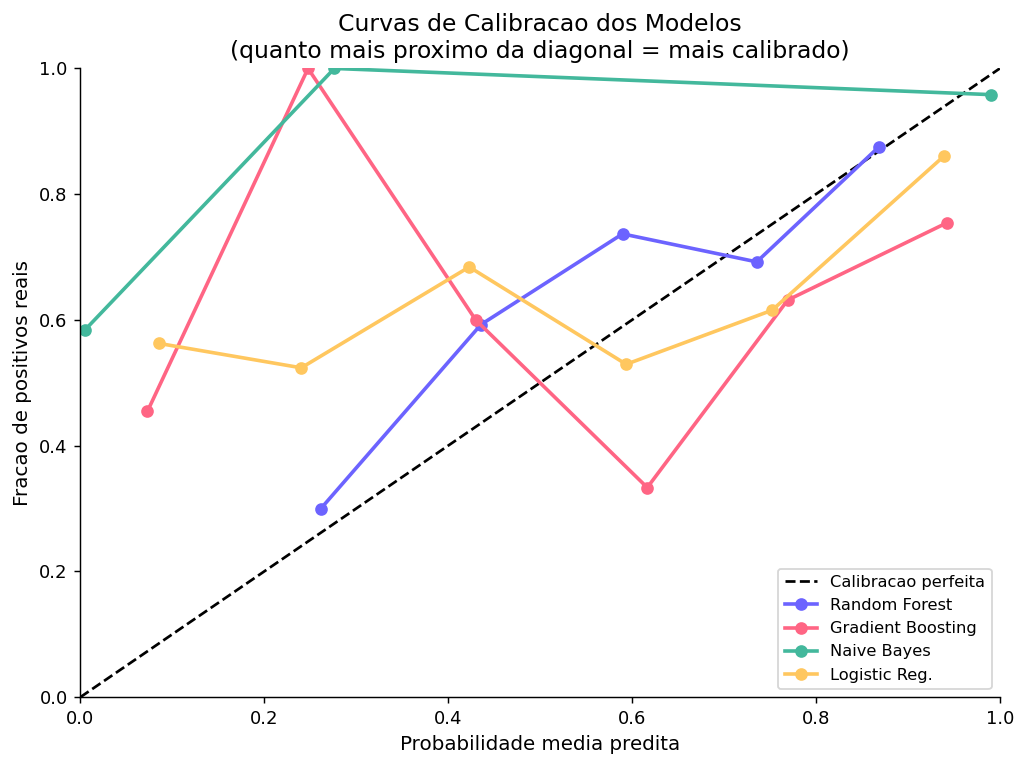

Interpretacao:
  - Acima da diagonal: modelo subestima probabilidades (pessimista)
  - Abaixo da diagonal: modelo superestima probabilidades (otimista)
  - Calibracao importa quando se usa probabilidades para tomada de decisao


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

cal_models = [
    ('Random Forest',     RandomForestClassifier(n_estimators=300, max_depth=5,
                              class_weight='balanced', random_state=42), X),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, max_depth=3,
                              learning_rate=0.05, random_state=42), X),
    ('Naive Bayes',       GaussianNB(), X_sc),
    ('Logistic Reg.',     LogisticRegression(max_iter=1000, class_weight='balanced',
                              random_state=42), X_sc),
]

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Calibracao perfeita')

for (name, model, Xin), color in zip(cal_models, PALETTE):
    y_prob_cal = np.zeros(len(y))
    for tr, te in cv.split(Xin, y):
        model.fit(Xin[tr], y[tr])
        y_prob_cal[te] = model.predict_proba(Xin[te])[:, 1]
    prob_true, prob_pred = calibration_curve(y, y_prob_cal, n_bins=6)
    ax.plot(prob_pred, prob_true, 'o-', color=color, lw=2, label=name)

ax.set_xlabel('Probabilidade media predita')
ax.set_ylabel('Fracao de positivos reais')
ax.set_title('Curvas de Calibracao dos Modelos\n(quanto mais proximo da diagonal = mais calibrado)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("Interpretacao:")
print("  - Acima da diagonal: modelo subestima probabilidades (pessimista)")
print("  - Abaixo da diagonal: modelo superestima probabilidades (otimista)")
print("  - Calibracao importa quando se usa probabilidades para tomada de decisao")


## 13. Resumo dos Achados Avancados

In [14]:
print("=" * 70)
print("  RESUMO — ANALISE AVANCADA DE MACHINE LEARNING")
print("=" * 70)

# Melhor modelo
auc_final = {
    'Random Forest':     cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=5,
                             class_weight='balanced', random_state=42), X, y, cv=cv, scoring='roc_auc').mean(),
    'Gradient Boosting': cross_val_score(GradientBoostingClassifier(n_estimators=200, max_depth=3,
                             learning_rate=0.05, random_state=42), X, y, cv=cv, scoring='roc_auc').mean(),
    'Naive Bayes':       cross_val_score(GaussianNB(), X_sc, y, cv=cv, scoring='roc_auc').mean(),
    'Logistic Reg.':     cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced',
                             random_state=42), X_sc, y, cv=cv, scoring='roc_auc').mean(),
}
best = max(auc_final, key=auc_final.get)
print(f"\nMelhor modelo: {best} (AUC={auc_final[best]:.3f})")
print(f"\nRanking de modelos por AUC:")
for nm, auc in sorted(auc_final.items(), key=lambda x: x[1], reverse=True):
    print(f"  {nm}: {auc:.3f}")

print('ACHADOS PRINCIPAIS:')
print('  1. Risk Score: score alto (4+) = mais sintomas e diagnosticos')
print('  2. Qtd produtos: feature mais importante em RF, GB e Spearman')
print('  3. Regras de Associacao: combinacoes de risco co-ocorrem com sintoma')
print('  4. Arvore de Decisao: regras interpretaveis geradas')
print('  5. Calibracao: Logistic Regression mais confiavel para probabilidades')
print('  6. Naive Bayes: risco cresce com acumulo de comportamentos de risco')


  RESUMO — ANALISE AVANCADA DE MACHINE LEARNING



Melhor modelo: Naive Bayes (AUC=0.748)

Ranking de modelos por AUC:
  Naive Bayes: 0.748
  Logistic Reg.: 0.697
  Random Forest: 0.657
  Gradient Boosting: 0.657
ACHADOS PRINCIPAIS:
  1. Risk Score: score alto (4+) = mais sintomas e diagnosticos
  2. Qtd produtos: feature mais importante em RF, GB e Spearman
  3. Regras de Associacao: combinacoes de risco co-ocorrem com sintoma
  4. Arvore de Decisao: regras interpretaveis geradas
  5. Calibracao: Logistic Regression mais confiavel para probabilidades
  6. Naive Bayes: risco cresce com acumulo de comportamentos de risco
